# Notebook 01 — Data Acquisition & GAD Calibration

**Kernel:** `quantdata` conda environment (Python 3.12)

```bash
conda activate quantdata
export QUANTDATA_ROOT=~/quantdata_data
mkdir -p ~/quantdata_data/{raw,processing,training,experiments}
```

Steps:
1. Download SPY daily prices 2010–2023 via Yahoo Finance (cached locally)
2. FIX calibration — estimate GAD params on the trailing 250-day window ending 2020-02-28
3. Rolling calibration robustness check — verify FIX params lie within the historical range
4. Download all S&P 500 constituent prices for the test period (March 2020 – Dec 2023)
5. Save everything to disk for Notebooks 02–03

In [1]:
import sys
import os
import json
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Project root ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("__file__").resolve().parent.parent
# If running from notebooks_outputs/, go one level up
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)
(DATA_DIR / "sp500_prices").mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")

Project root: /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness
Data dir:     /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/data


## 1. Download SPY prices

In [2]:
from quantdata.yahoo.client import YFClient

client = YFClient()

# Full history for calibration robustness check + rolling plot
SPY_START = date(2010, 1, 1)
SPY_END   = date(2023, 12, 31)

spy_df = client.prices("SPY", SPY_START, SPY_END)
print(f"SPY shape: {spy_df.shape}")
spy_df.head()

SPY shape: (3522, 8)


Price,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
2010-01-04,0.0,84.796371,0.0,84.841263,83.434602,84.078076,0.0,118944600.0
2010-01-05,0.0,85.020836,0.0,85.058249,84.437221,84.743996,0.0,111579900.0
2010-01-06,0.0,85.080711,0.0,85.290214,84.871209,84.938547,0.0,116074400.0
2010-01-07,0.0,85.439842,0.0,85.544593,84.684133,84.923565,0.0,131091100.0
2010-01-08,0.0,85.724167,0.0,85.761580,85.043285,85.215373,0.0,126402800.0


Saved SPY prices → /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/data/spy_prices.csv  (3522 rows)


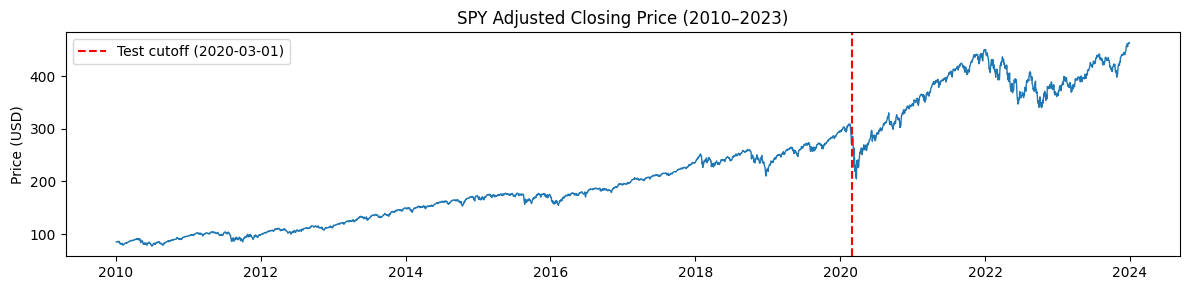

In [3]:
spy_prices = spy_df["Close"].dropna()
spy_prices.name = "Close"

# Save to disk (loaded by Notebooks 02–03 without quantdata)
spy_csv_path = DATA_DIR / "spy_prices.csv"
spy_prices.to_csv(spy_csv_path, header=True)
print(f"Saved SPY prices → {spy_csv_path}  ({len(spy_prices)} rows)")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(spy_prices.index, spy_prices.values, linewidth=1)
ax.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle="--", linewidth=1.5, label="Test cutoff (2020-03-01)")
ax.set_title("SPY Adjusted Closing Price (2010–2023)")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 2. FIX Calibration — trailing 250-day window ending 2020-02-28

In [4]:
from src.calibration.gad_calibration import calibrate_gad, rolling_calibration
from dataclasses import asdict

CUTOFF       = pd.Timestamp("2020-02-28")
CALIB_WINDOW = 250
S0_NORM      = 10.0
DT           = 1 / 252

# Extract the calibration window (raw prices)
spy_train = spy_prices[spy_prices.index <= CUTOFF].values
assert len(spy_train) >= CALIB_WINDOW, f"Need ≥{CALIB_WINDOW} pre-cutoff observations, got {len(spy_train)}"

calib_window = spy_train[-CALIB_WINDOW:]

# Show both raw and normalised ranges — calibrate_gad normalises internally,
# but making it explicit here confirms the regressions operate at S₀ = 10
S_norm = calib_window * (S0_NORM / calib_window[0])
print(f"Calibration window: {CALIB_WINDOW} days")
print(f"  Raw price range:        [{calib_window.min():.2f}, {calib_window.max():.2f}]")
print(f"  Normalised price range: [{S_norm.min():.4f}, {S_norm.max():.4f}]  (S₀ = {S0_NORM})")

# Both OLS regressions run on S_norm inside calibrate_gad
params_fix = calibrate_gad(calib_window, dt=DT, S0_target=S0_NORM)

print("\n── FIX Parameters (normalised price space, S₀ = 10) ────────────")
for k, v in asdict(params_fix).items():
    print(f"  {k:6s} = {v}")

Calibration window: 250 days
  Raw price range:        [246.16, 309.20]
  Normalised price range: [9.8366, 12.3556]  (S₀ = 10.0)

── FIX Parameters (normalised price space, S₀ = 10) ────────────
  b0     = 41.85224384738817
  b1     = -3.7657702527179233
  a0     = 0.5247584480969488
  a1     = 0.046182936501302
  gamma  = 1.0
  S0     = 10.0
  T      = 0.11904761904761904
  N      = 30
  M      = 100000


In [5]:
# Implied annualised volatility at S = 10
#
# In the SDE  dS = ... + (a0 + a1*S)*dW  (W a standard BM, Var(dW)=dt),
# the log-return process satisfies  d(log S) ≈ (a0+a1*S)/S * dW.
# The coefficient of dW is already annualised (BM has variance = time in years).
# No sqrt(252) factor — that would be needed only for a discrete daily std.
a0, a1 = params_fix.a0, params_fix.a1
annualised_vol = (a0 + a1 * S0_NORM) / S0_NORM

print(f"a0 = {a0:.6f}  (must be ≥ 0: {'✓' if a0 >= 0 else '✗ FAIL'})")
print(f"a1 = {a1:.6f}  (must be ≥ 0: {'✓' if a1 >= 0 else '✗ FAIL'})")
print()
print(f"Implied annualised vol at S=10: {annualised_vol:.2%}")

if 0.08 <= annualised_vol <= 0.30:
    print("  ✓ In expected range for SPY (8%–30%)")
else:
    print(f"  ⚠ OUTSIDE expected range 8%–30% — check calibration inputs")

# Verify diffusion is positive across the full normalised calibration window
diff_min = a0 + a1 * S_norm.min()
diff_max = a0 + a1 * S_norm.max()
print(f"\nDiffusion coefficient (a0 + a1*S) over calibration window:")
print(f"  min: {diff_min:.6f}  max: {diff_max:.6f}  "
      f"({'✓ all positive' if diff_min > 0 else '✗ negative — FAIL'})")

# Save to disk
params_path = DATA_DIR / "gad_params_fix.json"
with open(params_path, "w") as f:
    json.dump(asdict(params_fix), f, indent=2)
print(f"\nSaved GAD FIX params → {params_path}")

a0 = 0.524758  (must be ≥ 0: ✓)
a1 = 0.046183  (must be ≥ 0: ✓)

Implied annualised vol at S=10: 9.87%
  ✓ In expected range for SPY (8%–30%)

Diffusion coefficient (a0 + a1*S) over calibration window:
  min: 0.979040  max: 1.095378  (✓ all positive)

Saved GAD FIX params → /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/data/gad_params_fix.json


## 3. Rolling Calibration — Robustness Check

In [6]:
# Run rolling calibration on the full 2010–Feb 2020 window
spy_pre_cutoff = spy_prices[spy_prices.index <= CUTOFF].values

rolling_df = rolling_calibration(spy_pre_cutoff, window=CALIB_WINDOW, dt=DT, S0_target=S0_NORM)
print(f"Rolling estimates: {len(rolling_df)} windows")
rolling_df.describe().round(6)

Rolling estimates: 2307 windows


,b0,b1,a0,a1
count,2307.000000,2307.000000,2307.000000,2307.000000
mean,49.358197,-4.581733,5.419752,0.036864
std,37.548682,3.743106,4.640151,0.115498
min,-22.185666,-18.552542,0.000000,0.000000
25%,19.785228,-6.198400,1.533270,0.000000
50%,41.647503,-3.780395,3.894316,0.000000
75%,66.380532,-1.630396,9.568175,0.000000
max,201.745642,2.275249,17.744423,0.606319


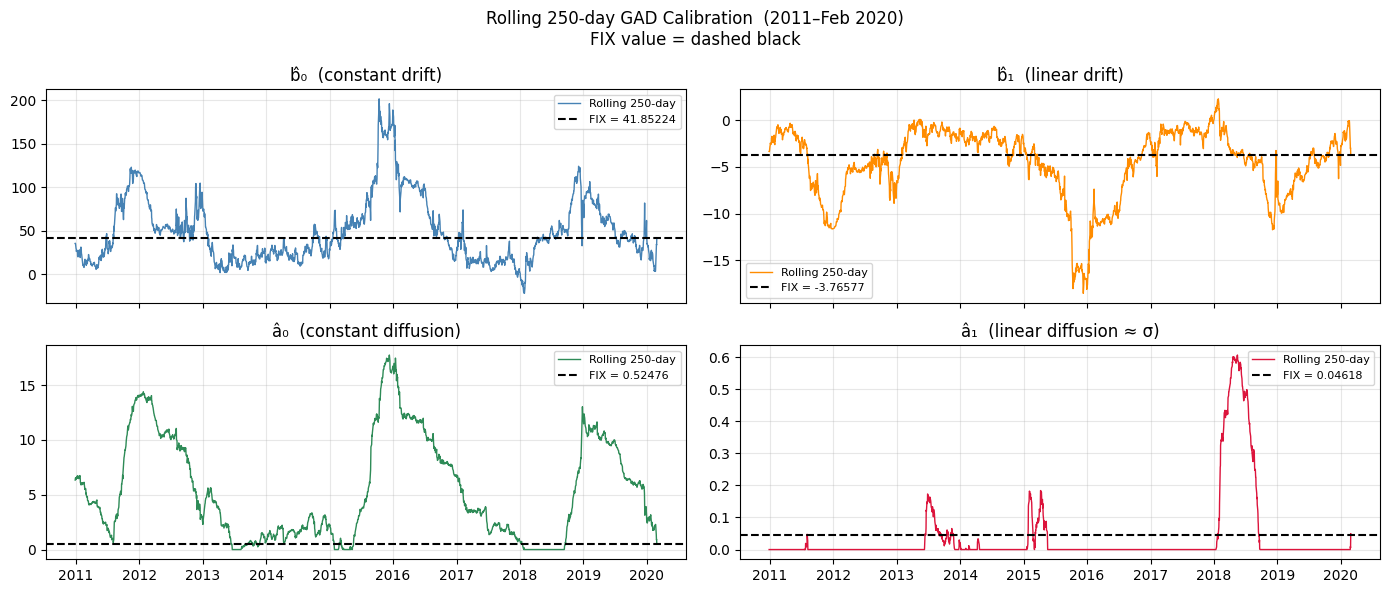

Saved rolling calibration plot.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)
params_to_plot = [
    ("b0", "b̂₀  (constant drift)", "steelblue"),
    ("b1", "b̂₁  (linear drift)", "darkorange"),
    ("a0", "â₀  (constant diffusion)", "seagreen"),
    ("a1", "â₁  (linear diffusion ≈ σ)", "crimson"),
]

dates_rolling = spy_prices[spy_prices.index <= CUTOFF].index[rolling_df.index]

for ax, (col, label, color) in zip(axes.flat, params_to_plot):
    ax.plot(dates_rolling, rolling_df[col].values, color=color, linewidth=1.0, label="Rolling 250-day")
    fix_val = asdict(params_fix)[col]
    ax.axhline(fix_val, color="black", linestyle="--", linewidth=1.5, label=f"FIX = {fix_val:.5f}")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Rolling 250-day GAD Calibration  (2011–Feb 2020)\nFIX value = dashed black", fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / "gad_rolling_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved rolling calibration plot.")

**Robustness check:** The FIX parameters should lie within the range of historical rolling estimates shown above. If any parameter is a clear outlier, consider using the median of the rolling estimates instead.

## 4. Download S&P 500 Constituent Prices (test period)

In [8]:
from src.real_data.sp500_loader import get_sp500_tickers

TEST_START = date(2020, 3, 1)
TEST_END   = date(2023, 12, 31)

tickers = get_sp500_tickers()
print(f"Found {len(tickers)} S&P 500 tickers")
print("First 10:", tickers[:10])

Found 502 S&P 500 tickers
First 10: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [9]:
import time

sp500_dir = DATA_DIR / "sp500_prices"
sp500_dir.mkdir(exist_ok=True)

failed   = []
skipped  = []
n_saved  = 0

for i, ticker in enumerate(tickers):
    out_path = sp500_dir / f"{ticker}.csv"
    if out_path.exists():
        skipped.append(ticker)
        continue
    try:
        df = client.prices(ticker, TEST_START, TEST_END)
        if len(df) < 30:
            failed.append((ticker, "too few rows"))
            continue
        df["Close"].dropna().to_csv(out_path, header=True)
        n_saved += 1
        if (i + 1) % 50 == 0:
            print(f"  [{i+1}/{len(tickers)}] saved={n_saved}  failed={len(failed)}  skipped={len(skipped)}")
    except Exception as exc:
        failed.append((ticker))

print(f"\nDone. Saved={n_saved}  Skipped={len(skipped)}  Failed={len(failed)}")
if failed:
    print("Failed tickers:")
    for t in failed[:20]:
        print(f"  {t}")

$FDXF: possibly delisted; no price data found  (1d 2020-03-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1583038800, endDate = 1703998800")

1 Failed download:
['FDXF']: possibly delisted; no price data found  (1d 2020-03-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1583038800, endDate = 1703998800")
$GEV: possibly delisted; no price data found  (1d 2020-03-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1583038800, endDate = 1703998800")

1 Failed download:
['GEV']: possibly delisted; no price data found  (1d 2020-03-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1583038800, endDate = 1703998800")
$Q: possibly delisted; no price data found  (1d 2020-03-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1583038800, endDate = 1703998800")

1 Failed download:
['Q']: possibly delisted; no price data found  (1d 2020-03-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDat


Done. Saved=0  Skipped=498  Failed=4
Failed tickers:
  FDXF
  GEV
  Q
  SOLV


## 5. Data Coverage Summary

In [10]:
csv_files   = sorted(sp500_dir.glob("*.csv"))
n_windows   = 0
row_counts  = []

T_WINDOW = 30

for f in csv_files:
    df = pd.read_csv(f, index_col=0)
    n_rows = len(df)
    row_counts.append(n_rows)
    n_windows += max(0, n_rows - T_WINDOW)

print(f"Tickers downloaded:  {len(csv_files)}")
print(f"Median rows/ticker:  {int(np.median(row_counts))}")
print(f"Total 30-day windows (before quality filter): {n_windows:,}")

Tickers downloaded:  498
Median rows/ticker:  966
Total 30-day windows (before quality filter): 461,513


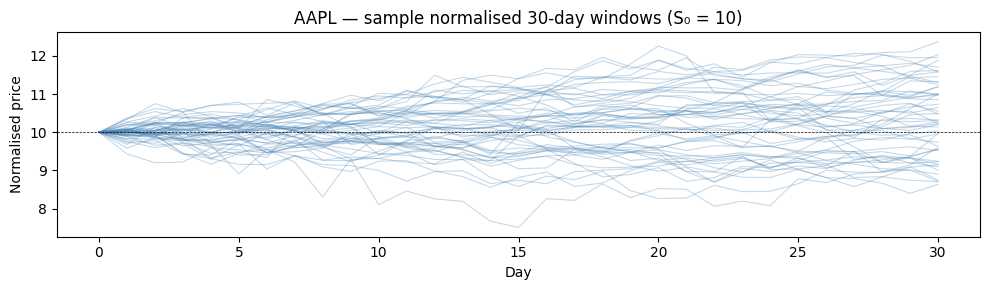

In [11]:
# Quick sanity: plot a few normalised windows for AAPL
aapl_path = sp500_dir / "AAPL.csv"
if aapl_path.exists():
    aapl_prices = pd.read_csv(aapl_path, index_col=0, parse_dates=True)["Close"].dropna().values
    n_aapl = len(aapl_prices)
    fig, ax = plt.subplots(figsize=(10, 3))
    step = max(1, (n_aapl - T_WINDOW) // 50)
    for start in range(0, n_aapl - T_WINDOW, step):
        window = aapl_prices[start : start + T_WINDOW + 1]
        if len(window) < T_WINDOW + 1:
            continue
        window_norm = window / window[0] * S0_NORM
        ax.plot(range(T_WINDOW + 1), window_norm, alpha=0.3, linewidth=0.8, color="steelblue")
    ax.axhline(S0_NORM, color="black", linewidth=0.5, linestyle="--")
    ax.set_title("AAPL — sample normalised 30-day windows (S₀ = 10)")
    ax.set_xlabel("Day")
    ax.set_ylabel("Normalised price")
    plt.tight_layout()
    plt.show()

## Summary

| Item | Value |
|---|---|
| GAD FIX calibration window | 250 days ending 2020-02-28 |
| FIX parameters saved | `data/gad_params_fix.json` |
| SPY prices saved | `data/spy_prices.csv` |
| S&P 500 prices saved | `data/sp500_prices/<TICKER>.csv` |
| Expected test-set size | ~25k–50k normalised 30-day windows |

**Next:** Run `02_gad_training.ipynb` in the deep-hedging environment.